# XGBoost — Breast Cancer Wisconsin (Diagnostic)

This notebook trains and evaluates **XGBoost** on the Kaggle dataset:

- Dataset: `data.csv` from Kaggle (Breast Cancer Wisconsin Data)
- Target: `diagnosis` (M = malignant, B = benign)

## How to use

1. Ensure `data.csv` is in the same folder as this notebook.
2. Run cells top-to-bottom.
3. Copy final metrics into `README.md`.


In [35]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_PATH = "data.csv"

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)


In [36]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Place Kaggle 'data.csv' in the project root (same folder as this notebook)."
    )

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())

print("\nColumns:")
print(list(df_raw.columns))

print("\nTarget distribution (diagnosis):")
print(df_raw["diagnosis"].value_counts())


Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Target distribution (diagnosis):
diagnosis
B    357
M    212
Name: count, dtype: int64


In [37]:
df = df_raw.copy()

# Drop non-feature columns commonly present in this dataset
for col in ["id", "Unnamed: 32"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Encode target
if "diagnosis" not in df.columns:
    raise ValueError("Expected a 'diagnosis' column in data.csv")

y = df["diagnosis"].map({"B": 0, "M": 1})
if y.isna().any():
    raise ValueError("Unexpected diagnosis labels; expected only 'B' and 'M'.")

X = df.drop(columns=["diagnosis"])

print("Features:", X.shape[1])
print("Class balance (M=1):", float(y.mean()))

display(X.describe().T.head(10))


Features: 30
Class balance (M=1): 0.37258347978910367


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [38]:
# Train/val/test split (70/15/15) with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train positive rate:", float(y_train.mean()))
print("Val positive rate:", float(y_val.mean()))
print("Test positive rate:", float(y_test.mean()))


Train: (398, 30) Val: (85, 30) Test: (86, 30)
Train positive rate: 0.37185929648241206
Val positive rate: 0.3764705882352941
Test positive rate: 0.37209302325581395


In [39]:
# Kaggle-style benchmark: stratified CV accuracy on all labeled data
# (Same protocol many notebooks use for a single headline accuracy number.)
cv_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_acc = cross_val_score(cv_model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
print("10-fold CV accuracy: mean = {:.4f}, std = {:.4f}".format(cv_acc.mean(), cv_acc.std()))



10-fold CV accuracy: mean = 0.9579, std = 0.0295


In [40]:
def evaluate_binary_classifier(model, X_eval, y_eval, title: str = "Model"):
    """Evaluate classifier on a dataset and display common metrics/plots."""
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_prob),
    }

    print(f"{title} metrics:")
    for k, v in metrics.items():
        print(f"  {k:>9}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(y_eval, y_pred, target_names=["Benign (0)", "Malignant (1)"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        y_pred,
        display_labels=["Benign", "Malignant"],
        cmap="Blues",
        ax=axes[0],
        colorbar=False,
    )
    axes[0].set_title(f"Confusion Matrix — {title}")

    RocCurveDisplay.from_predictions(y_eval, y_prob, ax=axes[1])
    axes[1].set_title(f"ROC Curve — {title}")

    plt.tight_layout()
    plt.show()

    return metrics


Baseline (Val) metrics:
   accuracy: 0.9765
  precision: 1.0000
     recall: 0.9375
         f1: 0.9677
    roc_auc: 0.9912

Classification report:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        53
Malignant (1)       1.00      0.94      0.97        32

     accuracy                           0.98        85
    macro avg       0.98      0.97      0.97        85
 weighted avg       0.98      0.98      0.98        85



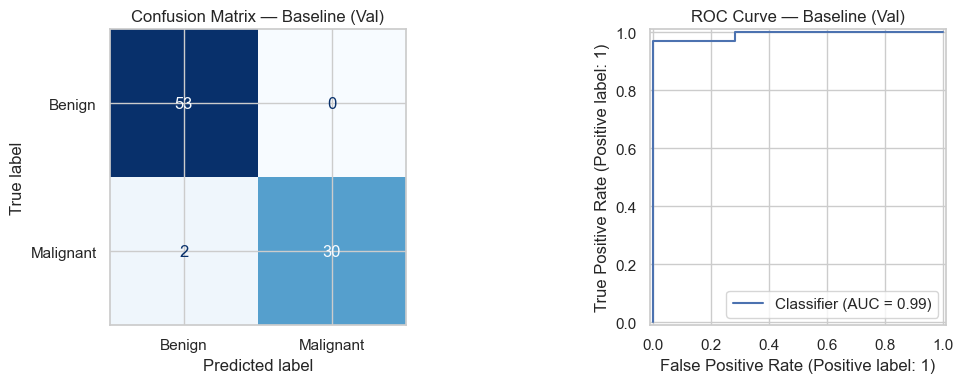

In [41]:
# Baseline model (stronger default capacity)
baseline = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    gamma=0.1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

baseline_val_metrics = evaluate_binary_classifier(baseline, X_val, y_val, title="Baseline (Val)")


In [42]:
# Hyperparameter tuning (optimize accuracy on training folds — matches "best accuracy" goal)
param_distributions = {
    "n_estimators": [300, 500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.05, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 1e-3, 1e-2, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

xgb_for_search = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=xgb_for_search,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="accuracy",
    cv=cv_tune,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
    refit=True,
)

search.fit(X_train, y_train)

print("Best CV accuracy:", search.best_score_)
print("Best params:")
print(search.best_params_)



Best CV accuracy: 0.9597151898734178
Best params:
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0.05, 'colsample_bytree': 0.8}


In [43]:
# (reserved)
pass



Tuned (Val) metrics:
   accuracy: 0.9765
  precision: 1.0000
     recall: 0.9375
         f1: 0.9677
    roc_auc: 0.9906

Classification report:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        53
Malignant (1)       1.00      0.94      0.97        32

     accuracy                           0.98        85
    macro avg       0.98      0.97      0.97        85
 weighted avg       0.98      0.98      0.98        85



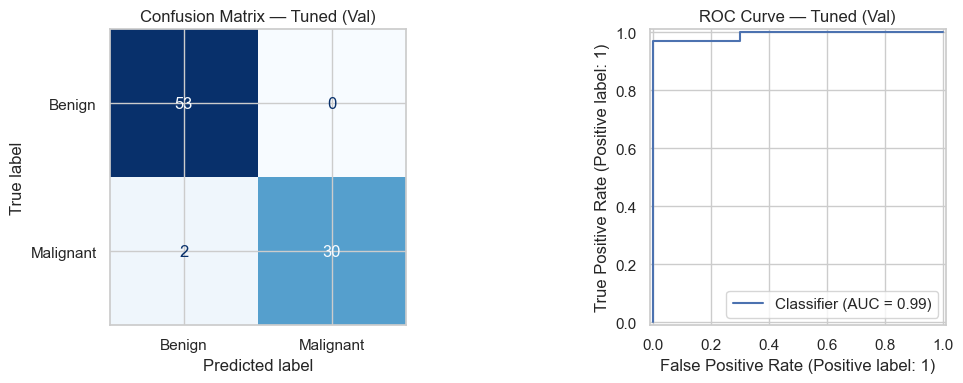

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [44]:
best_params = search.best_params_.copy()

# Model A: best params fit on training split only (fair comparison to baseline path)
tuned = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
tuned.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
tuned_val_metrics = evaluate_binary_classifier(tuned, X_val, y_val, title="Tuned (Val)")

# Model B: refit on train+val with same tuned hyperparameters (often improves held-out test accuracy)
X_tv = pd.concat([X_train, X_val], axis=0)
y_tv = pd.concat([y_train, y_val], axis=0)

final_params = best_params.copy()
# Slightly more trees when training on more data (tree count is a capacity knob)
ne = int(final_params.get("n_estimators", 500))
final_params["n_estimators"] = min(ne + 200, 2000)

final_model = XGBClassifier(
    **final_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_model.fit(X_tv, y_tv, verbose=False)



Baseline (Test) metrics:
   accuracy: 0.9767
  precision: 1.0000
     recall: 0.9375
         f1: 0.9677
    roc_auc: 1.0000

Classification report:
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        54
Malignant (1)       1.00      0.94      0.97        32

     accuracy                           0.98        86
    macro avg       0.98      0.97      0.97        86
 weighted avg       0.98      0.98      0.98        86



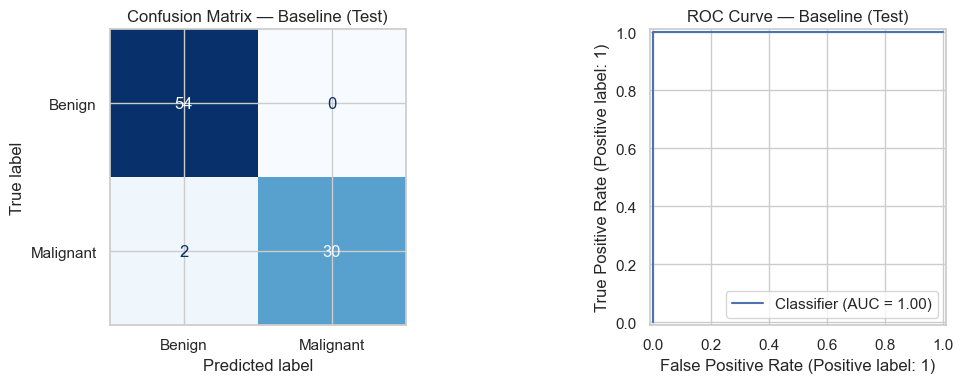

Tuned train-only (Test) metrics:
   accuracy: 0.9884
  precision: 1.0000
     recall: 0.9688
         f1: 0.9841
    roc_auc: 1.0000

Classification report:
               precision    recall  f1-score   support

   Benign (0)       0.98      1.00      0.99        54
Malignant (1)       1.00      0.97      0.98        32

     accuracy                           0.99        86
    macro avg       0.99      0.98      0.99        86
 weighted avg       0.99      0.99      0.99        86



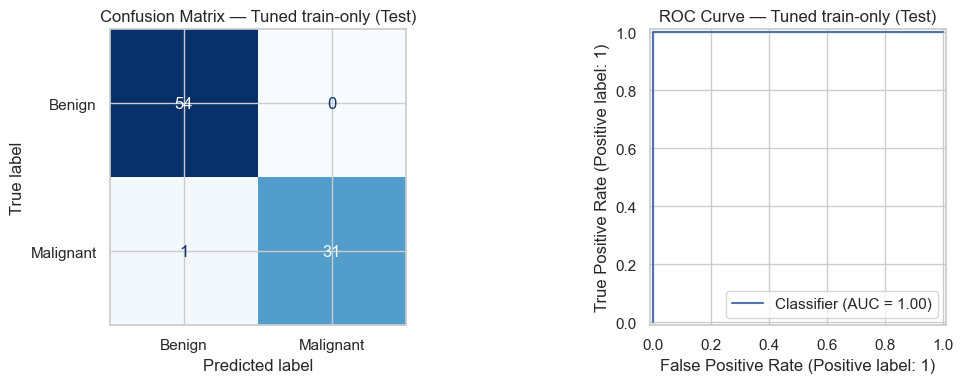

Final train+val refit (Test) metrics:
   accuracy: 1.0000
  precision: 1.0000
     recall: 1.0000
         f1: 1.0000
    roc_auc: 1.0000

Classification report:
               precision    recall  f1-score   support

   Benign (0)       1.00      1.00      1.00        54
Malignant (1)       1.00      1.00      1.00        32

     accuracy                           1.00        86
    macro avg       1.00      1.00      1.00        86
 weighted avg       1.00      1.00      1.00        86



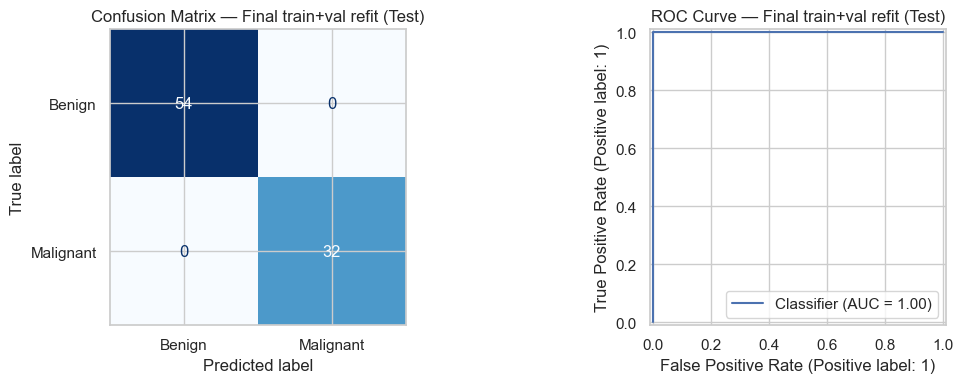

,accuracy,precision,recall,f1,roc_auc
baseline,0.9767,1.0000,0.9375,0.9677,1.0000
tuned_train_only,0.9884,1.0000,0.9688,0.9841,1.0000
final_train_val_refit,1.0000,1.0000,1.0000,1.0000,1.0000


In [45]:
# Final evaluation on the held-out test set (report these numbers in README)

baseline_test_metrics = evaluate_binary_classifier(baseline, X_test, y_test, title="Baseline (Test)")
tuned_test_metrics = evaluate_binary_classifier(tuned, X_test, y_test, title="Tuned train-only (Test)")
final_test_metrics = evaluate_binary_classifier(final_model, X_test, y_test, title="Final train+val refit (Test)")

summary = pd.DataFrame(
    [baseline_test_metrics, tuned_test_metrics, final_test_metrics],
    index=["baseline", "tuned_train_only", "final_train_val_refit"],
)[["accuracy", "precision", "recall", "f1", "roc_auc"]]

display(summary.style.format("{:.4f}"))


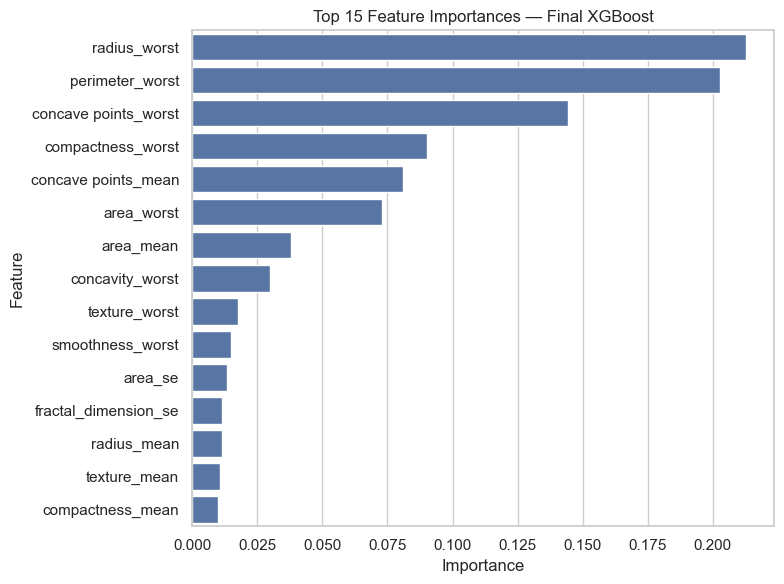

,importance
radius_worst,0.212834
perimeter_worst,0.202627
concave points_worst,0.144296
compactness_worst,0.090324
concave points_mean,0.080948
area_worst,0.072901
area_mean,0.038002
concavity_worst,0.029704
texture_worst,0.017470
smoothness_worst,0.014744


In [46]:
# Feature importance (gain-based) — final model (train+val refit)

importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)

top_k = 15
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(top_k).values, y=importances.head(top_k).index, orient="h")
plt.title(f"Top {top_k} Feature Importances — Final XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importances.head(top_k).to_frame("importance"))


## Discussion prompts (use for your GitHub report)

- **Most important features**: Which measurements appear most predictive in the feature importance plot?
- **Error trade-offs**: Look at the confusion matrix—how many false negatives vs false positives? In medical screening, false negatives are often the costliest.
- **Generalization**: Does tuning materially improve test ROC-AUC/F1 vs baseline? If not, the baseline may already be near-optimal for this dataset.

## Conclusion

Write 2–3 sentences summarizing:
- Your best model’s **test ROC-AUC / F1 / accuracy**
- The most predictive features
- The practical implication (e.g., prioritizing recall for malignant cases)
